# 결과 해석 및 인사이트 도출

> 가설 검증 결과, gate 위치 변경이 retention에 통계적으로 유의한 영향을 미친다고 보기 어려웠다.  
> 이에 따라 유저 행동 패턴 분석과 세그먼트 관점의 추가 분석을 진행한다.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("../data/cookie_cats.csv")
df.head(5)

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [3]:
df = df[df['sum_gamerounds'] != 0]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 86195 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          86195 non-null  int64 
 1   version         86195 non-null  object
 2   sum_gamerounds  86195 non-null  int64 
 3   retention_1     86195 non-null  bool  
 4   retention_7     86195 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.8+ MB


In [4]:
conditions = [
    (df['retention_1'] == False) & (df['retention_7'] == False),
    (df['retention_1'] == False) & (df['retention_7'] == True),
    (df['retention_1'] == True) & (df['retention_7'] == False),
    (df['retention_1'] == True) & (df['retention_7'] == True)
]

choices = ['E', 'A', 'C', 'R']

df['retention_group'] = np.select(conditions, choices, default='U')
df.sample(10)

,userid,version,sum_gamerounds,retention_1,retention_7,retention_group
56633,6276510,gate_30,45,True,True,R
72655,8048953,gate_30,45,True,False,C
73156,8102927,gate_30,2,False,False,E
11294,1247830,gate_30,77,False,True,A
17347,1931163,gate_40,79,True,False,C
45261,5013580,gate_30,10,False,False,E
46272,5126059,gate_30,838,True,True,R
44652,4945079,gate_40,19,True,False,C
11049,1221044,gate_30,1,False,False,E
76427,8463382,gate_30,29,False,False,E


retention 그룹별 sum_gamerounds 분포
> - E : F/F
> - A : F/T
> - C : T/F
> - R : T/T

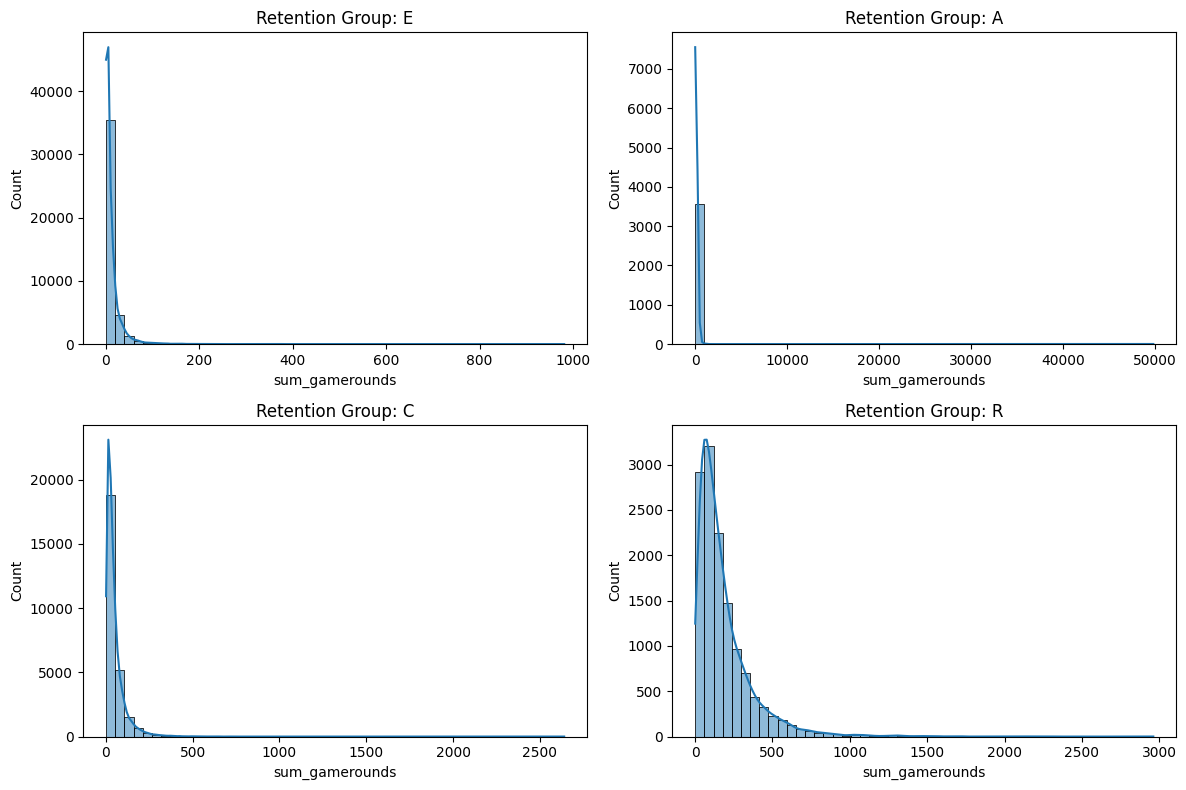

In [5]:
groups = ['E', 'A', 'C', 'R']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, group in zip(axes.flatten(), groups):
    
    sub_df = df[df['retention_group'] == group]
    
    sns.histplot(
        data=sub_df,
        x='sum_gamerounds',
        bins=50,
        kde=True,
        ax=ax
    )
    
    ax.set_title(f'Retention Group: {group}')
    ax.set_xlabel('sum_gamerounds')
    ax.set_ylabel('Count')

    # 축 통일
    # ax.set_xlim(0, 3000)
    # ax.set_ylim(0, 20000)

plt.tight_layout()
plt.show()

In [7]:
df[df['retention_group'] == 'A']['sum_gamerounds'].describe()

count     3575.000000
mean        88.622657
std        837.833863
min          1.000000
25%         19.000000
50%         45.000000
75%         95.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64

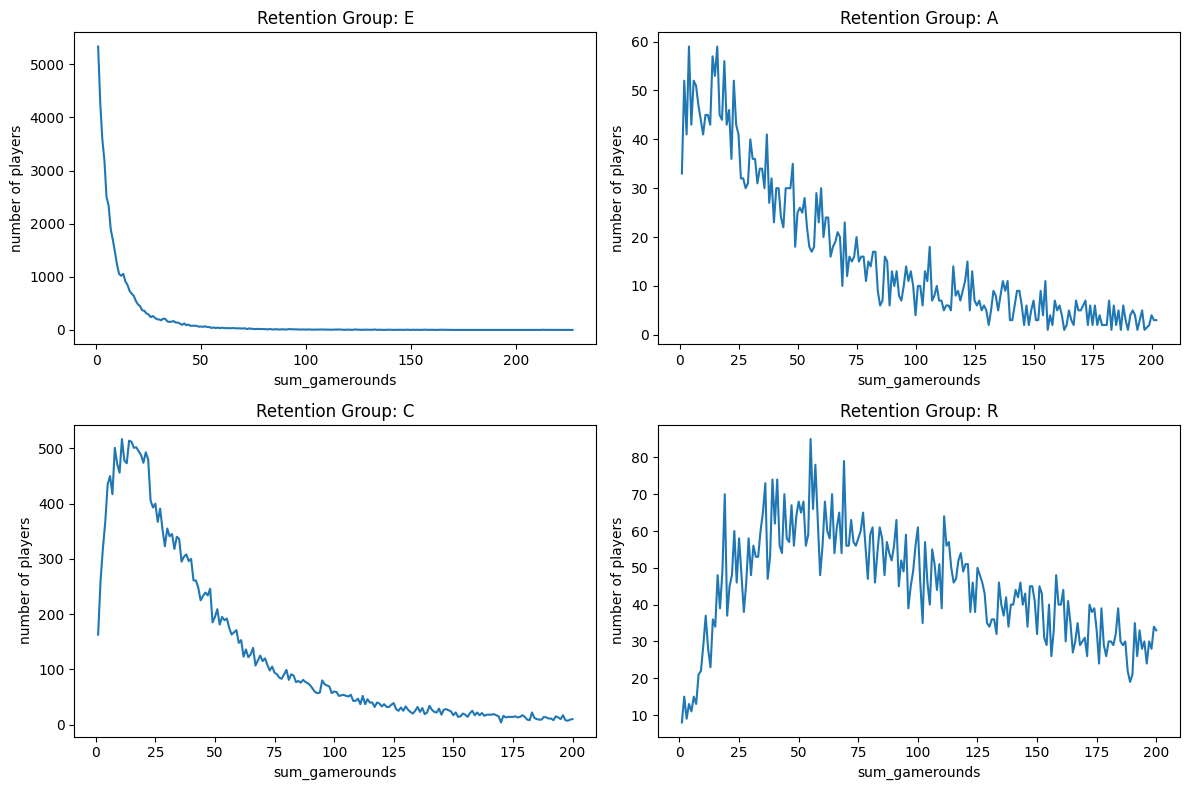

In [16]:
groups = ['E', 'A', 'C', 'R']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, group in zip(axes.flatten(), groups):

    sub_df = df[df['retention_group'] == group]

    # sum_gameround 기준 count
    plot_df = sub_df.groupby('sum_gamerounds')['userid'].count()

    # 상위 100개 gamerounds까지만 시각화
    plot_df.head(200).plot(ax=ax)

    ax.set_title(f'Retention Group: {group}')
    ax.set_xlabel('sum_gamerounds')
    ax.set_ylabel('number of players')

plt.tight_layout()
plt.show()

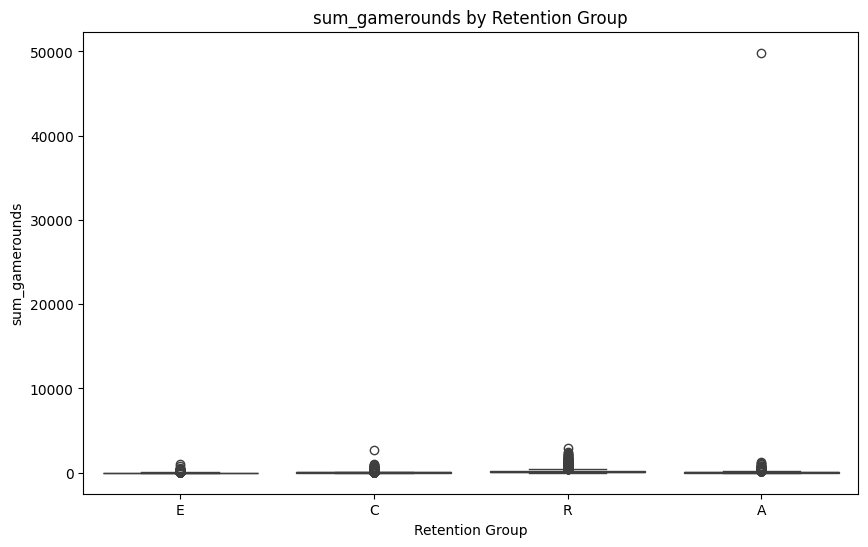

In [8]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='retention_group',
    y='sum_gamerounds'
)

plt.title('sum_gamerounds by Retention Group')
plt.xlabel('Retention Group')
plt.ylabel('sum_gamerounds')

plt.show()

In [9]:
# 극단치 잠시 제외
tmp = df.copy()

df = df[df['sum_gamerounds'] != 49854]

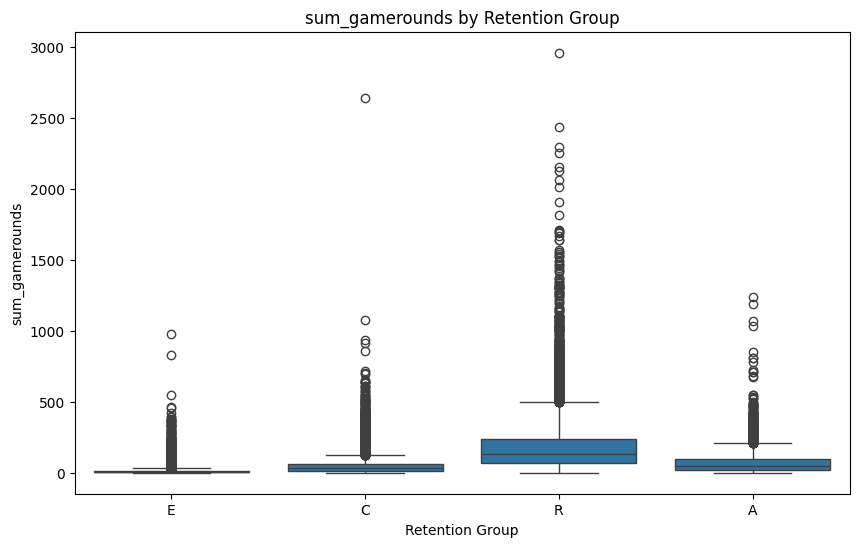

In [10]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='retention_group',
    y='sum_gamerounds'
)

plt.title('sum_gamerounds by Retention Group')
plt.xlabel('Retention Group')
plt.ylabel('sum_gamerounds')

plt.show()

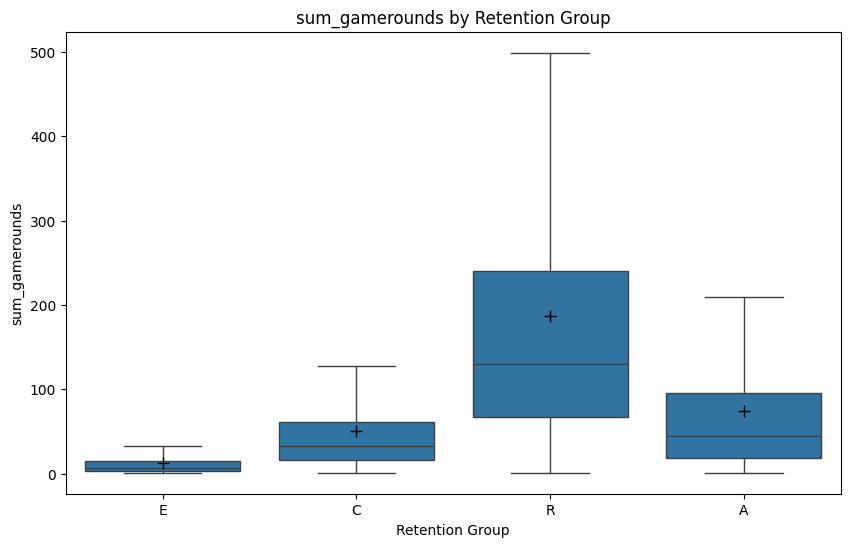

In [11]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='retention_group',
    y='sum_gamerounds',
    showmeans=True,
    meanprops={
        'marker': '+',
        'markerfacecolor': 'red',
        'markeredgecolor': 'black',
        'markersize': 8
    },
    showfliers=False
)

plt.title('sum_gamerounds by Retention Group')
plt.xlabel('Retention Group')
plt.ylabel('sum_gamerounds')

plt.show()

sum_gamerounds를 14일로 나눠 하루 평균 플레이한 stage 수 파생변수 생성

In [12]:
df['normalized_gamerounds'] = round(df['sum_gamerounds'] / 14, 0).astype(int)
df.head(5)

,userid,version,sum_gamerounds,retention_1,retention_7,retention_group,normalized_gamerounds
0,116,gate_30,3,False,False,E,0
1,337,gate_30,38,True,False,C,3
2,377,gate_40,165,True,False,C,12
3,483,gate_40,1,False,False,E,0
4,488,gate_40,179,True,True,R,13


sum_gamerounds Q1 ~ Q4 기준으로 플레이량 구간화
- 플레이량 수준에 따라 유저를 4개의 그룹으로 나누어 비교
- 0 데이터는 제외 극단치는 포함 (단, log 변환)

In [13]:
sg_df = tmp
sg_df

,userid,version,sum_gamerounds,retention_1,retention_7,retention_group
0,116,gate_30,3,False,False,E
1,337,gate_30,38,True,False,C
2,377,gate_40,165,True,False,C
3,483,gate_40,1,False,False,E
4,488,gate_40,179,True,True,R
...,...,...,...,...,...,...
90184,9999441,gate_40,97,True,False,C
90185,9999479,gate_40,30,False,False,E
90186,9999710,gate_30,28,True,False,C
90187,9999768,gate_40,51,True,False,C


In [17]:
sg_df['iqr_group'] = pd.qcut(
    sg_df['sum_gamerounds'],
    q=4,
    labels=['Q1', 'Q2', 'Q3', 'Q4']
)

sg_df

,userid,version,sum_gamerounds,retention_1,retention_7,retention_group,iqr_group
0,116,gate_30,3,False,False,E,Q1
1,337,gate_30,38,True,False,C,Q3
2,377,gate_40,165,True,False,C,Q4
3,483,gate_40,1,False,False,E,Q1
4,488,gate_40,179,True,True,R,Q4
...,...,...,...,...,...,...,...
90184,9999441,gate_40,97,True,False,C,Q4
90185,9999479,gate_40,30,False,False,E,Q3
90186,9999710,gate_30,28,True,False,C,Q3
90187,9999768,gate_40,51,True,False,C,Q3


In [19]:
sg_df.groupby(['iqr_group', 'retention_group'])['retention_group'].count()

C:\Users\wjswl\AppData\Local\Temp\ipykernel_2268\895959501.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sg_df.groupby(['iqr_group', 'retention_group'])['retention_group'].count()


iqr_group  retention_group
Q1         A                    280
           C                   1993
           E                  21240
           R                     71
Q2         A                    574
           C                   5838
           E                  13242
           R                    379
Q3         A                   1181
           C                  11208
           E                   6668
           R                   2070
Q4         A                   1540
           C                   7850
           E                   1404
           R                  10657
Name: retention_group, dtype: int64

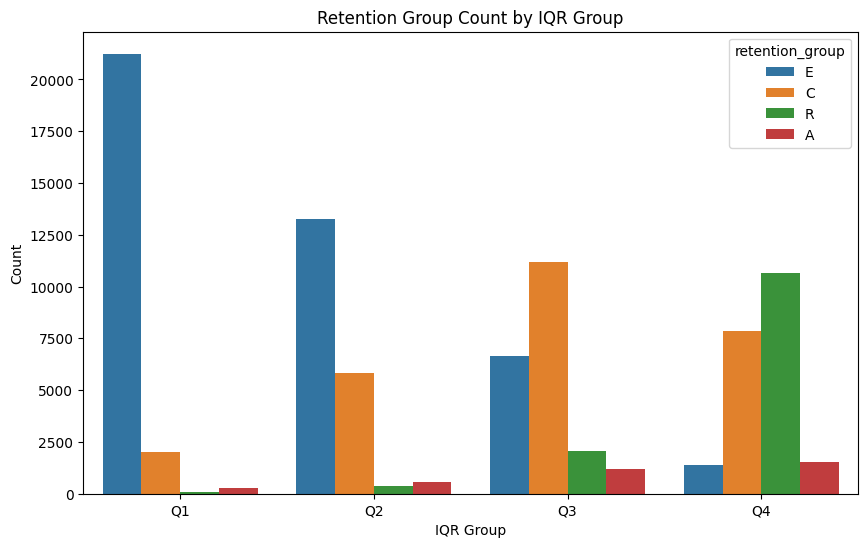

In [ ]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=sg_df,
    x='iqr_group',
    hue='retention_group'
)

plt.title('Retention Group Count by IQR Group')
plt.xlabel('IQR Group')
plt.ylabel('Count')

plt.show()

C:\Users\wjswl\AppData\Local\Temp\ipykernel_2268\1047328974.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub_df
C:\Users\wjswl\AppData\Local\Temp\ipykernel_2268\1047328974.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub_df
C:\Users\wjswl\AppData\Local\Temp\ipykernel_2268\1047328974.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub_df
C:\Users\wjswl\AppData\Local\Temp\ipykernel_2268\1047328974.py:1

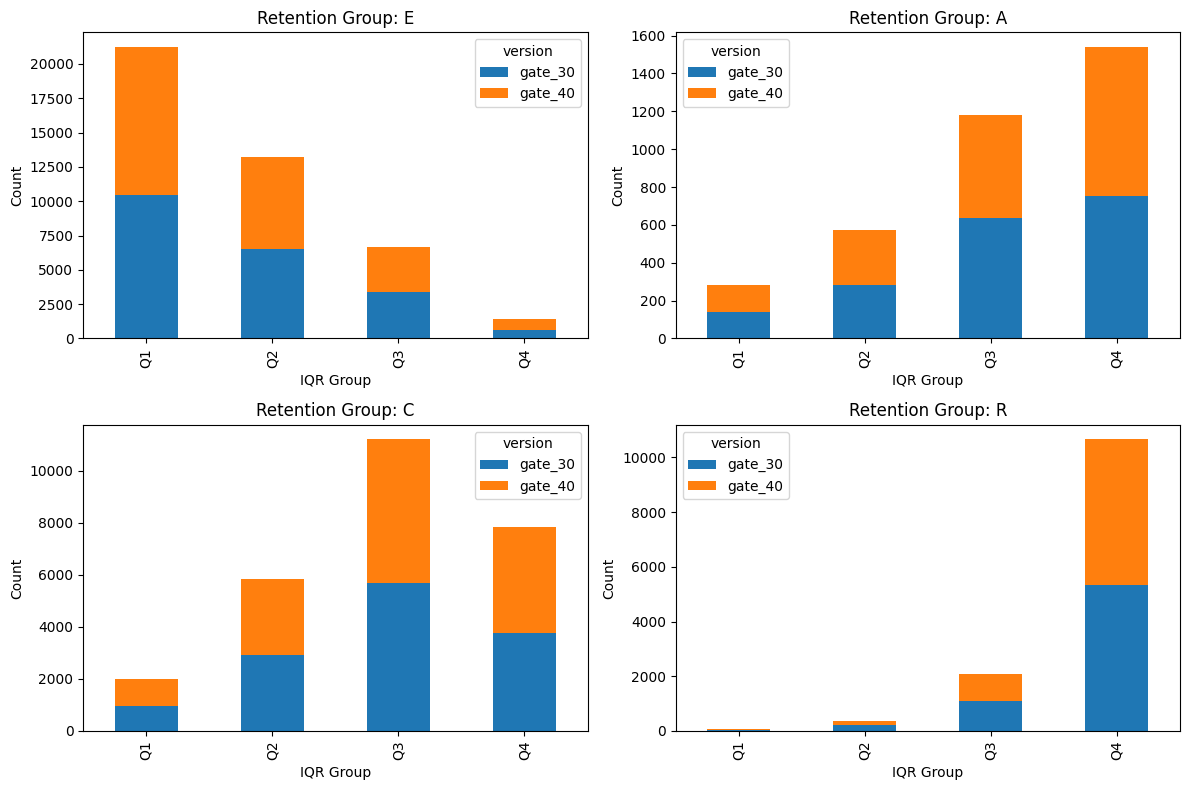

In [23]:
groups = ['E', 'A', 'C', 'R']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, group in zip(axes.flatten(), groups):

    sub_df = sg_df[sg_df['retention_group'] == group]

    plot_df = (
        sub_df
        .groupby(['iqr_group', 'version'])
        .size()
        .unstack(fill_value=0)
    )

    plot_df.plot(
        kind='bar',
        stacked=True,
        ax=ax
    )

    ax.set_title(f'Retention Group: {group}')
    ax.set_xlabel('IQR Group')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()